<a href="https://colab.research.google.com/github/whistle-hikhi/Decision-Tree/blob/main/gradient_boosting_house_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Mon Apr 14 07:22:38 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%load_ext cuml.accel

[2025-04-14 07:23:04.428] [CUML] [info] cuML: Installed accelerator for sklearn.
[2025-04-14 07:23:40.381] [CUML] [info] cuML: Installed accelerator for umap.
[2025-04-14 07:23:40.490] [CUML] [info] cuML: Installed accelerator for hdbscan.
[2025-04-14 07:23:40.490] [CUML] [info] cuML: Successfully initialized accelerator.


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
data = pd.read_csv(url)

In [5]:
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [6]:
X = data.drop('medv', axis=1)
y = data['medv']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
%%time
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
gb_model.fit(X_train, y_train)

CPU times: user 268 ms, sys: 1.19 ms, total: 269 ms
Wall time: 285 ms


GradientBoostingRegressor()

In [12]:
y_pred = gb_model.predict(X_test)

In [14]:
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Gradient Boosting R2 Score:", r2_score(y_test, y_pred))

Gradient Boosting RMSE: 3.087900714287804
Gradient Boosting R2 Score: 0.8706026257859881


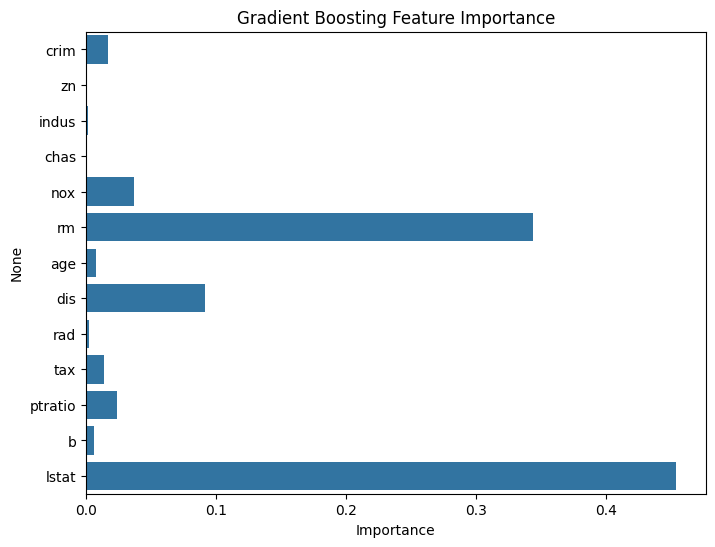

In [17]:
# Feature importance
feature_importance = pd.Series(gb_model.feature_importances_, index=data.columns[:-1])
plt.figure(figsize=(8, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('Gradient Boosting Feature Importance')
plt.xlabel('Importance')
plt.show()

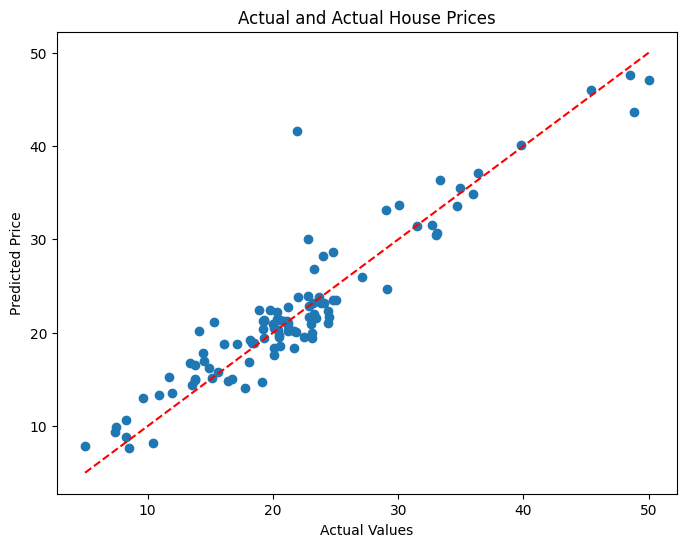

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Price')
plt.title('Actual and Actual House Prices')
plt.show()